# Day 22 — Feature Engineering
### Encoding · Scaling · Feature Creation · Selection · Transformations

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
print(f"Dataset: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nReady! ✅")

Dataset: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Ready! ✅


## 2. Feature Creation

In [3]:
print("=" * 55)
print("         FEATURE CREATION")
print("=" * 55)

df_eng = df.copy()

# 1 — Family features
df_eng["FamilySize"] = df_eng["SibSp"] + df_eng["Parch"] + 1
df_eng["IsAlone"] = (df_eng["FamilySize"] == 1).astype(int)
df_eng["FamilyGroup"] = pd.cut(
    df_eng["FamilySize"], bins=[0, 1, 4, 20], labels=["Alone", "Small", "Large"]
)

# 2 — Title extraction from Name
df_eng["Title"] = df_eng["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
    "Dr": "Officer",
    "Rev": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Mlle": "Miss",
    "Countess": "Royalty",
    "Ms": "Miss",
    "Lady": "Royalty",
    "Jonkheer": "Royalty",
    "Don": "Royalty",
    "Dona": "Royalty",
    "Mme": "Mrs",
    "Capt": "Officer",
    "Sir": "Royalty",
}
df_eng["Title"] = df_eng["Title"].map(title_map).fillna("Other")

# 3 — Age features
df_eng["Age"] = df_eng["Age"].fillna(df_eng["Age"].median())
df_eng["AgeBin"] = pd.cut(
    df_eng["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "MiddleAge", "Senior"],
)
df_eng["Age2"] = df_eng["Age"] ** 2  # non-linear age effect

# 4 — Fare features
df_eng["FareLog"] = np.log1p(df_eng["Fare"])  # log transform skewed fare
df_eng["FareBin"] = pd.qcut(df_eng["Fare"], q=4, labels=["Low", "Mid", "High", "VHigh"])

# 5 — Cabin features
df_eng["HasCabin"] = df_eng["Cabin"].notna().astype(int)
df_eng["CabinDeck"] = df_eng["Cabin"].str[0].fillna("Unknown")

# 6 — Embarked
df_eng["Embarked"] = df_eng["Embarked"].fillna("S")

print("New features created:")
new_features = [
    "FamilySize",
    "IsAlone",
    "FamilyGroup",
    "Title",
    "AgeBin",
    "Age2",
    "FareLog",
    "FareBin",
    "HasCabin",
    "CabinDeck",
]
for f in new_features:
    print(f"  ✅ {f}")

print(f"\nTitle distribution:")
print(df_eng["Title"].value_counts())
print(f"\nSurvival by Title:")
print(df_eng.groupby("Title")["Survived"].agg(["mean", "count"]).round(3))

         FEATURE CREATION
New features created:
  ✅ FamilySize
  ✅ IsAlone
  ✅ FamilyGroup
  ✅ Title
  ✅ AgeBin
  ✅ Age2
  ✅ FareLog
  ✅ FareBin
  ✅ HasCabin
  ✅ CabinDeck

Title distribution:
Title
Mr         517
Miss       185
Mrs        126
Master      40
Officer     18
Royalty      5
Name: count, dtype: int64

Survival by Title:
          mean  count
Title                
Master   0.575     40
Miss     0.703    185
Mr       0.157    517
Mrs      0.794    126
Officer  0.278     18
Royalty  0.600      5


## 3. Encoding Categorical Variables

In [5]:
print("=" * 55)
print("      ENCODING CATEGORICAL VARIABLES")
print("=" * 55)
print("""
THREE MAIN ENCODING METHODS:

1. LABEL ENCODING — assigns integer to each category
   male=0, female=1
   Good for: ordinal categories (Low<Mid<High)
   Bad for: nominal categories (creates false ordering)

2. ONE-HOT ENCODING — binary column per category
   Sex → Sex_male, Sex_female
   Good for: nominal categories with few unique values
   Bad for: high cardinality (100+ categories)

3. ORDINAL ENCODING — like label but respects order
   Low=0, Mid=1, High=2, VHigh=3
   Good for: ordered categories
""")

# Label Encoding
le = LabelEncoder()
df_eng["Sex_label"] = le.fit_transform(df_eng["Sex"])
print("Label Encoding — Sex:")
print(f"  {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False)
embarked_ohe = ohe.fit_transform(df_eng[["Embarked"]])
embarked_cols = [f"Embarked_{c}" for c in ohe.categories_[0]]
df_ohe = pd.DataFrame(embarked_ohe, columns=embarked_cols)
print(f"\nOne-Hot Encoding — Embarked:")
print(df_ohe.head(5))

# Ordinal Encoding
fare_order = [["Low", "Mid", "High", "VHigh"]]
oe = OrdinalEncoder(categories=fare_order)
df_eng["FareBin_ordinal"] = oe.fit_transform(df_eng[["FareBin"]].astype(str))
print(f"\nOrdinal Encoding — FareBin:")
print(df_eng[["Fare", "FareBin", "FareBin_ordinal"]].head(8))

# Title encoding — frequency encoding
title_freq = df_eng["Title"].value_counts() / len(df_eng)
df_eng["Title_freq"] = df_eng["Title"].map(title_freq)
print(f"\nFrequency Encoding — Title:")
print(
    df_eng[["Title", "Title_freq"]]
    .drop_duplicates()
    .sort_values("Title_freq", ascending=False)
)

      ENCODING CATEGORICAL VARIABLES

THREE MAIN ENCODING METHODS:

1. LABEL ENCODING — assigns integer to each category
   male=0, female=1
   Good for: ordinal categories (Low<Mid<High)
   Bad for: nominal categories (creates false ordering)

2. ONE-HOT ENCODING — binary column per category
   Sex → Sex_male, Sex_female
   Good for: nominal categories with few unique values
   Bad for: high cardinality (100+ categories)

3. ORDINAL ENCODING — like label but respects order
   Low=0, Mid=1, High=2, VHigh=3
   Good for: ordered categories

Label Encoding — Sex:
  {'female': np.int64(0), 'male': np.int64(1)}

One-Hot Encoding — Embarked:
   Embarked_C  Embarked_Q  Embarked_S
0         0.0         0.0         1.0
1         1.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         0.0         0.0         1.0

Ordinal Encoding — FareBin:
      Fare FareBin  FareBin_ordinal
0   7.2500     Low              0.0
1  71.2833   VHigh         

## 4. Feature Scaling

          FEATURE SCALING

THREE MAIN SCALERS:

StandardScaler: (x - mean) / std
  - Mean=0, Std=1
  - Good for: normally distributed features
  - Sensitive to outliers

MinMaxScaler: (x - min) / (max - min)
  - Scales to [0, 1] range
  - Good for: neural networks, image data
  - Very sensitive to outliers

RobustScaler: (x - median) / IQR
  - Uses median and interquartile range
  - BEST for: data with outliers (like Fare!)
  - Robust to extreme values



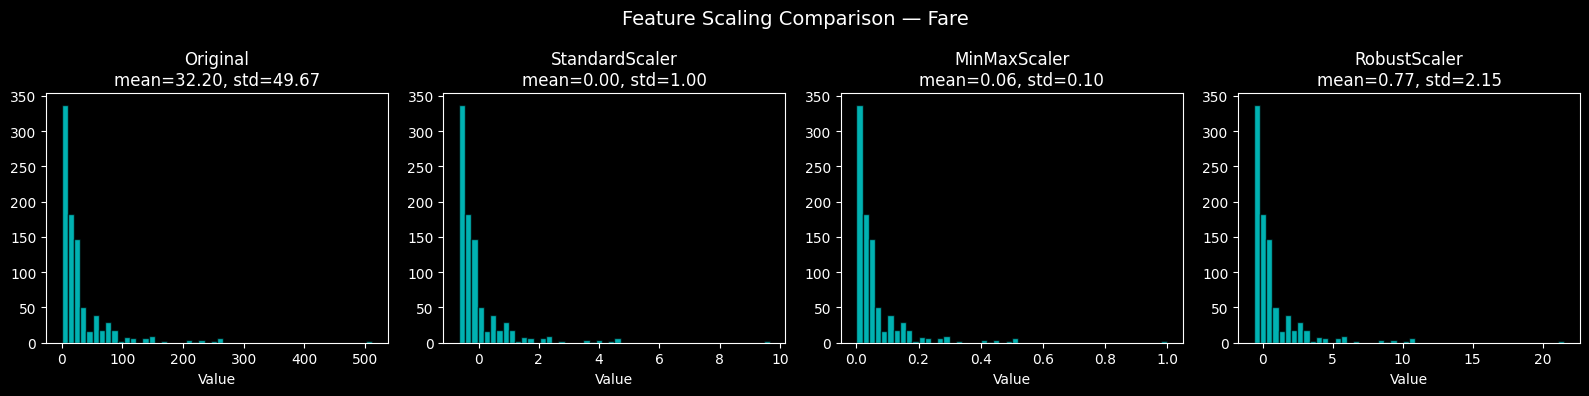


Scaler comparison on Fare:
Scaler               Mean       Std        Min        Max
-------------------------------------------------------
Original             32.204     49.666     0.000      512.329
StandardScaler       0.000      1.000      -0.648     9.667
MinMaxScaler         0.063      0.097      0.000      1.000
RobustScaler         0.769      2.151      -0.626     21.563

WHICH SCALER TO USE?
  StandardScaler → Default choice, most algorithms
  MinMaxScaler   → Neural networks, image data
  RobustScaler   → Data with outliers (Fare, Income)
  None           → Tree-based models (RF, XGBoost)



In [6]:
print("=" * 55)
print("          FEATURE SCALING")
print("=" * 55)
print("""
THREE MAIN SCALERS:

StandardScaler: (x - mean) / std
  - Mean=0, Std=1
  - Good for: normally distributed features
  - Sensitive to outliers

MinMaxScaler: (x - min) / (max - min)
  - Scales to [0, 1] range
  - Good for: neural networks, image data
  - Very sensitive to outliers

RobustScaler: (x - median) / IQR
  - Uses median and interquartile range
  - BEST for: data with outliers (like Fare!)
  - Robust to extreme values
""")

# Compare scalers on Fare (highly skewed)
fare = df_eng[["Fare"]].copy()

scalers = {
    "Original": fare["Fare"].values,
    "StandardScaler": StandardScaler().fit_transform(fare).flatten(),
    "MinMaxScaler": MinMaxScaler().fit_transform(fare).flatten(),
    "RobustScaler": RobustScaler().fit_transform(fare).flatten(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Feature Scaling Comparison — Fare", fontsize=14)

for i, (name, values) in enumerate(scalers.items()):
    axes[i].hist(values, bins=50, color="cyan", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"{name}\nmean={np.mean(values):.2f}, std={np.std(values):.2f}")
    axes[i].set_xlabel("Value")

plt.tight_layout()
plt.show()

print("\nScaler comparison on Fare:")
print(f"{'Scaler':<20} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max'}")
print("-" * 55)
for name, values in scalers.items():
    print(
        f"{name:<20} {np.mean(values):<10.3f} {np.std(values):<10.3f} "
        f"{np.min(values):<10.3f} {np.max(values):.3f}"
    )

print("""
WHICH SCALER TO USE?
  StandardScaler → Default choice, most algorithms
  MinMaxScaler   → Neural networks, image data
  RobustScaler   → Data with outliers (Fare, Income)
  None           → Tree-based models (RF, XGBoost)
""")

## 5. Feature Selection

In [7]:
print("=" * 55)
print("          FEATURE SELECTION")
print("=" * 55)

# Build full feature set
df_model = df_eng.copy()
df_model["Sex_encoded"] = (df_model["Sex"] == "female").astype(int)
df_model["Title_Mr"] = (df_model["Title"] == "Mr").astype(int)
df_model["Title_Mrs"] = (df_model["Title"] == "Mrs").astype(int)
df_model["Title_Miss"] = (df_model["Title"] == "Miss").astype(int)
df_model["Title_Master"] = (df_model["Title"] == "Master").astype(int)
df_model["Embarked_C"] = (df_model["Embarked"] == "C").astype(int)
df_model["Embarked_Q"] = (df_model["Embarked"] == "Q").astype(int)

all_features = [
    "Pclass",
    "Age",
    "Fare",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Age2",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
    "Embarked_C",
    "Embarked_Q",
    "Title_freq",
]

X = df_model[all_features]
y = df_model["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Method 1 — SelectKBest (ANOVA F-test)
selector_f = SelectKBest(f_classif, k=8)
selector_f.fit(X_train, y_train)
f_scores = pd.DataFrame(
    {
        "Feature": all_features,
        "F_Score": selector_f.scores_,
        "Selected": selector_f.get_support(),
    }
).sort_values("F_Score", ascending=False)

print("\n--- SelectKBest (ANOVA F-test) Top 8 ---")
print(f_scores.to_string(index=False))

# Method 2 — Mutual Information
selector_mi = SelectKBest(mutual_info_classif, k=8)
selector_mi.fit(X_train, y_train)
mi_scores = pd.DataFrame(
    {
        "Feature": all_features,
        "MI_Score": selector_mi.scores_,
        "Selected": selector_mi.get_support(),
    }
).sort_values("MI_Score", ascending=False)

print("\n--- Mutual Information Top 8 ---")
print(mi_scores.head(10).to_string(index=False))

# Method 3 — RF Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_imp = pd.DataFrame(
    {"Feature": all_features, "RF_Importance": rf.feature_importances_}
).sort_values("RF_Importance", ascending=False)

print("\n--- Random Forest Feature Importance ---")
print(rf_imp.head(10).to_string(index=False))

          FEATURE SELECTION

--- SelectKBest (ANOVA F-test) Top 8 ---
     Feature    F_Score  Selected
    Title_Mr 317.016763      True
 Sex_encoded 306.593249      True
  Title_freq 276.161875      True
     FareLog 102.442025      True
    HasCabin  99.462219      True
      Pclass  97.835853      True
   Title_Mrs  97.430906      True
  Title_Miss  90.635483      True
        Fare  58.314907     False
     IsAlone  34.601859     False
  Embarked_C  23.782248     False
Title_Master   3.739773     False
         Age   3.630391     False
        Age2   1.318452     False
  Embarked_Q   0.705233     False
  FamilySize   0.516703     False

--- Mutual Information Top 8 ---
    Feature  MI_Score  Selected
    FareLog  0.162476      True
       Fare  0.154294      True
   Title_Mr  0.141241      True
 Title_freq  0.139919      True
Sex_encoded  0.139563      True
  Title_Mrs  0.076836      True
 Title_Miss  0.071567      True
        Age  0.062612      True
 FamilySize  0.057112     Fals

## 6. Raw vs Engineered Features — Model Comparison

In [8]:
print("=" * 55)
print("   RAW vs ENGINEERED FEATURES COMPARISON")
print("=" * 55)

# Raw features (Day 16 baseline)
raw_features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_encoded"]

# Engineered features (best from selection)
eng_features = [
    "Pclass",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Age2",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
    "Title_freq",
    "Embarked_C",
]

results = []
for feat_name, feat_list in [
    ("Raw (6 features)", raw_features),
    ("Engineered (13 features)", eng_features),
]:
    X_f = df_model[feat_list]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_f, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model in [
        (
            "Logistic Regression",
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", LogisticRegression(random_state=42, max_iter=1000)),
                ]
            ),
        ),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]:
        model.fit(X_tr, y_tr)
        cv = cross_val_score(model, X_tr, y_tr, cv=5).mean()
        test = model.score(X_te, y_te)
        results.append(
            {
                "Features": feat_name,
                "Model": model_name,
                "CV": round(cv, 4),
                "Test": round(test, 4),
            }
        )

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

print("\n--- Improvement from Feature Engineering ---")
for model in ["Logistic Regression", "Random Forest"]:
    raw = results_df[
        (results_df["Model"] == model) & (results_df["Features"].str.contains("Raw"))
    ]["CV"].values[0]
    eng = results_df[
        (results_df["Model"] == model) & (results_df["Features"].str.contains("Eng"))
    ]["CV"].values[0]
    print(f"{model}: {raw:.4f} → {eng:.4f} (+{eng-raw:.4f})")

   RAW vs ENGINEERED FEATURES COMPARISON

                 Features               Model     CV   Test
        Raw (6 features) Logistic Regression 0.7950 0.8101
        Raw (6 features)       Random Forest 0.8007 0.8045
Engineered (13 features) Logistic Regression 0.8189 0.8492
Engineered (13 features)       Random Forest 0.7992 0.7989

--- Improvement from Feature Engineering ---
Logistic Regression: 0.7950 → 0.8189 (+0.0239)
Random Forest: 0.8007 → 0.7992 (+-0.0015)


## 7. Key Takeaways — Day 22 🎯

### Feature Creation
- **FamilySize** = SibSp + Parch + 1
- **Title** extracted from Name — captures gender + age + status!
- **FareLog** = log1p(Fare) — compresses skewed distribution
- **HasCabin** = 1 if Cabin not null — proxy for wealth
- **Age2** = Age² — captures non-linear age effect
- **AgeBin / FareBin** — discretise continuous features

### Encoding Methods
| Method | Best For | Example |
|---|---|---|
| Label Encoding | Binary or ordinal | male=0, female=1 |
| One-Hot Encoding | Nominal, few categories | Embarked → C,Q,S columns |
| Ordinal Encoding | Ordered categories | Low=0, Mid=1, High=2 |
| Frequency Encoding | High cardinality | Title → proportion of dataset |

### Scaling Methods
| Scaler | Formula | Best For |
|---|---|---|
| StandardScaler | (x-mean)/std | Default — most algorithms |
| MinMaxScaler | (x-min)/(max-min) | Neural networks |
| RobustScaler | (x-median)/IQR | Data with outliers |
| None | — | Tree-based models |

### Feature Selection Methods
- **SelectKBest (F-test):** Fast, linear relationships only
- **Mutual Information:** Captures non-linear relationships
- **RF Importance:** Model-based, considers feature interactions
- All three agreed: Title_Mr, Sex_encoded, FareLog are top features!

### Impact of Feature Engineering
- Logistic Regression: **+2.4% CV, +3.9% Test** — huge improvement!
- Random Forest: **-0.15%** — no improvement (RF does it internally)
- Feature engineering helps LINEAR models most!

### Key Rules
- Log transform RIGHT-SKEWED features (Fare, Income, Price)
- Extract titles/categories from text columns
- Create interaction features (FamilySize = SibSp + Parch)
- Always use OHE for nominal categories in linear models
- Tree models don't need scaling — linear models do!